# Day 19 – Explainable ML + MLOps
### 20-Day ML Revision Planner | Phase: ML Engineering

**Topics covered:**
1. Explainability: Feature Importance & Permutation Importance
2. Partial Dependence Plots
3. SHAP (SHapley Additive exPlanations)
4. LIME (Local Interpretable Model-agnostic Explanations)
5. ML Engineering: Model Serialization & Pipelines
6. Experiment Tracking, Model Versioning, Data Versioning
7. Data Drift & Model Drift
8. Monitoring and Retraining
9. Deployment Concepts: Data → Preprocessing → Model → API → Docker → Cloud → Monitoring
10. Coding: Save a Model, Expose a Prediction Function/API, Document a Monitoring Plan
11. One-Page ML Lifecycle Diagram (Daily Output)
12. Interview Questions
13. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)

print("SHAP available:", SHAP_AVAILABLE)
print("LIME available:", LIME_AVAILABLE)


SHAP available: True
LIME available: True


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load and prepare the Breast Cancer dataset (used throughout today for explainability demos)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])
model_pipeline.fit(X_train, y_train)

print(f"Test accuracy: {accuracy_score(y_test, model_pipeline.predict(X_test)):.4f}")


Test accuracy: 0.9580


## 1. Feature Importance & Permutation Importance

### What?
- **(Built-in) Feature Importance** (recap from Day 7/9): for tree-based models, measures how much each feature reduces impurity (Gini/entropy) across all splits where it's used, summed and normalized.
- **Permutation Importance**: a **model-agnostic** alternative — randomly **shuffle** one feature's values (breaking its relationship with the target) and measure how much the model's performance **drops**. A larger drop means the feature was more important.

### Why?
Built-in tree importance has known biases — it can **overstate the importance of high-cardinality or continuous features** simply because they offer more possible split points, not necessarily because they're more predictive. Permutation importance is more robust and works for **any** model type (not just trees), since it only requires the ability to make predictions.

### How?
`sklearn.inspection.permutation_importance` shuffles each feature (repeated multiple times for stability) and measures the resulting drop in a chosen scoring metric, computed on **held-out data** (to reflect genuine generalization impact, not just training-set memorization).


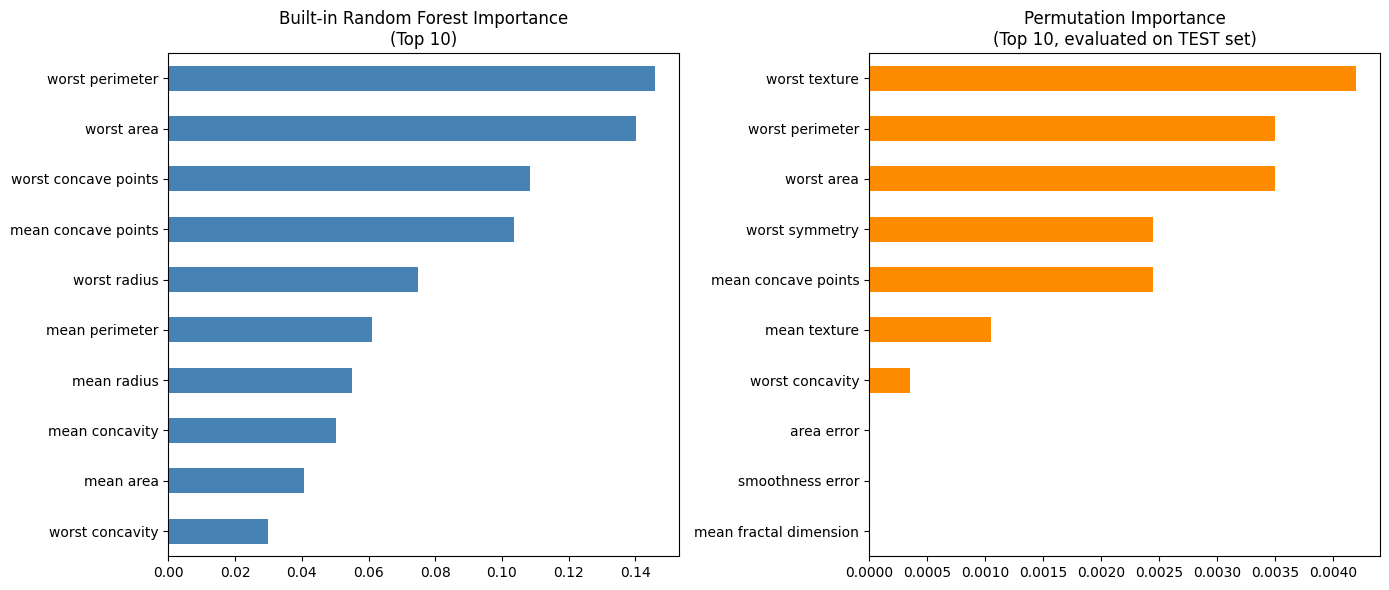

Overlap in top-10 features between the two methods: 4 out of 10
--> They often agree substantially but can differ meaningfully, especially when correlated
    features let built-in importance 'split credit' inconsistently across them.


In [3]:
# Compare built-in Random Forest importance vs Permutation Importance
rf_model = model_pipeline.named_steps['clf']
builtin_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

perm_result = permutation_importance(model_pipeline, X_test, y_test, n_repeats=20, random_state=42, scoring='accuracy')
perm_importance = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
builtin_importance.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis(); axes[0].set_title("Built-in Random Forest Importance\n(Top 10)")

perm_importance.head(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis(); axes[1].set_title("Permutation Importance\n(Top 10, evaluated on TEST set)")

plt.tight_layout()
plt.show()

overlap = set(builtin_importance.head(10).index) & set(perm_importance.head(10).index)
print(f"Overlap in top-10 features between the two methods: {len(overlap)} out of 10")
print("--> They often agree substantially but can differ meaningfully, especially when correlated")
print("    features let built-in importance 'split credit' inconsistently across them.")


## 2. Partial Dependence Plots (PDP)

### What?
A **Partial Dependence Plot** shows how the model's **average predicted outcome** changes as **one feature varies**, while averaging out (marginalizing over) the effect of all other features.

### Why?
Feature importance tells you **which** features matter; PDP tells you **how** — e.g., does increasing "mean radius" always increase the probability of malignancy, or is the relationship non-monotonic (increases then plateaus, or even reverses)?

### How?
For a grid of values of the feature of interest, PDP repeatedly asks: "if EVERY sample in the dataset had this feature value, what would the average prediction be?" — plotting the resulting curve.


Generating PDPs for: ['worst perimeter', 'worst area']


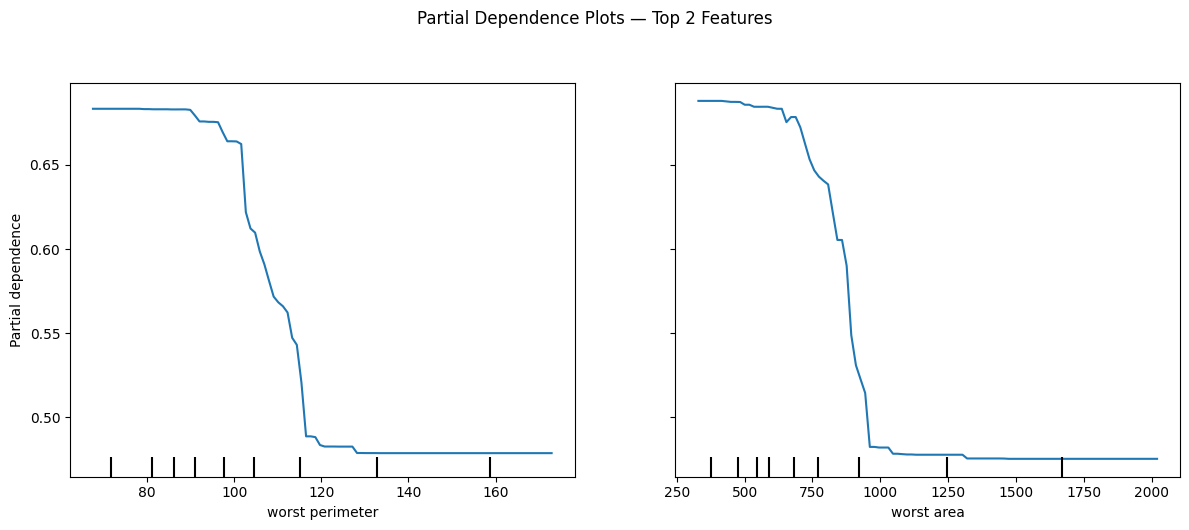

--> Notice how the predicted probability of the POSITIVE class (benign) tends to change
    as each feature's value increases, holding the marginal effect of all other features constant.


In [4]:
# Partial Dependence Plot for the top 2 most important features
top_2_features = builtin_importance.head(2).index.tolist()
print(f"Generating PDPs for: {top_2_features}")

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(model_pipeline, X_train, top_2_features, ax=ax)
plt.suptitle("Partial Dependence Plots — Top 2 Features", y=1.05)
plt.tight_layout()
plt.show()
print("--> Notice how the predicted probability of the POSITIVE class (benign) tends to change")
print("    as each feature's value increases, holding the marginal effect of all other features constant.")


## 3. SHAP (SHapley Additive exPlanations)

### What?
SHAP assigns each feature a **contribution value** for a specific prediction, grounded in **Shapley values** from cooperative game theory: it fairly distributes the "credit" for a prediction among all features, by considering every possible **order** in which features could be "added" to reach the final prediction.

$$f(x) = \phi_0 + \sum_i \phi_i$$

where $\phi_0$ is the average/baseline prediction, and each $\phi_i$ is feature $i$'s SHAP value (its contribution, positive or negative, for this specific prediction).

### Why?
SHAP provides both:
- **Local explanations**: "why did the model predict THIS for THIS specific sample?" (which features pushed the prediction up/down, and by how much)
- **Global explanations**: aggregating SHAP values across many samples reveals overall feature importance and even interaction effects — a full, theoretically-grounded, consistent explanation framework unifying several older methods (including a form of Partial Dependence).

### How?
`TreeExplainer` provides fast, exact SHAP values for tree-based models (like our Random Forest); `KernelExplainer` is a slower, fully model-agnostic alternative for any model type.


In [5]:
# SHAP: global summary (feature importance + direction of effect) and local (single-prediction) explanations
if SHAP_AVAILABLE:
    X_test_scaled_for_shap = model_pipeline.named_steps['scaler'].transform(X_test)
    X_test_scaled_df = pd.DataFrame(X_test_scaled_for_shap, columns=X.columns, index=X_test.index)

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_scaled_df)

    # For binary classification, shap_values may be a list [class0, class1] or a single array depending on version
    if isinstance(shap_values, list):
        shap_values_positive_class = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values_positive_class = shap_values[:, :, 1]
    else:
        shap_values_positive_class = shap_values

    print(f"SHAP values shape: {shap_values_positive_class.shape} (samples x features)")
    print("Each value represents that feature's contribution to THAT sample's prediction (for the positive class).")
else:
    print("SHAP not installed. Install with: pip install shap")


SHAP values shape: (143, 30) (samples x features)
Each value represents that feature's contribution to THAT sample's prediction (for the positive class).


/tmp/ipykernel_102/1075459837.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_positive_class, X_test_scaled_df, show=False)


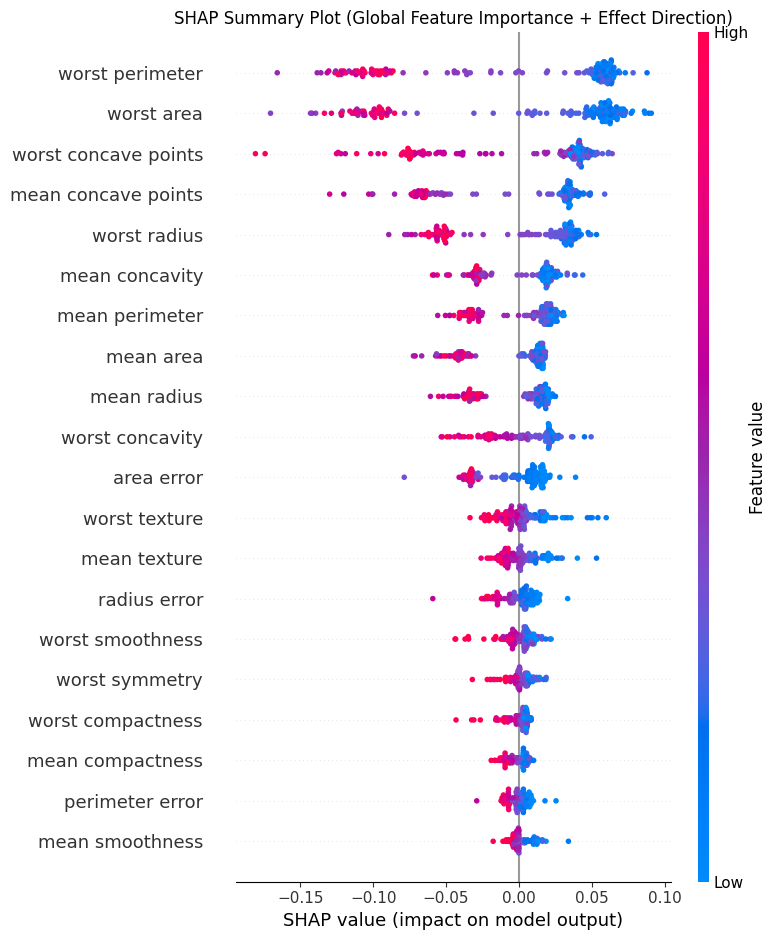

--> Each dot is one sample. Color = feature value (red=high, blue=low). Position on the
    x-axis = SHAP value (impact on prediction). This shows BOTH importance AND direction
    of effect for every feature at once -- richer than a plain importance bar chart.


In [6]:
# SHAP summary plot -- global view: which features matter most, and in which direction
if SHAP_AVAILABLE:
    shap.summary_plot(shap_values_positive_class, X_test_scaled_df, show=False)
    plt.title("SHAP Summary Plot (Global Feature Importance + Effect Direction)")
    plt.tight_layout()
    plt.show()
    print("--> Each dot is one sample. Color = feature value (red=high, blue=low). Position on the")
    print("    x-axis = SHAP value (impact on prediction). This shows BOTH importance AND direction")
    print("    of effect for every feature at once -- richer than a plain importance bar chart.")


In [7]:
# SHAP local explanation: explain ONE specific prediction in detail
if SHAP_AVAILABLE:
    sample_idx = 0
    sample_prediction = model_pipeline.predict(X_test.iloc[[sample_idx]])[0]
    sample_probability = model_pipeline.predict_proba(X_test.iloc[[sample_idx]])[0]

    print(f"Explaining prediction for test sample #{sample_idx}:")
    print(f"  Predicted class: {data.target_names[sample_prediction]}")
    print(f"  Predicted probabilities: {dict(zip(data.target_names, sample_probability.round(3)))}")
    print(f"  Actual class: {data.target_names[y_test.iloc[sample_idx]]}")

    # Show the top contributing features for this specific sample
    sample_shap_values = pd.Series(shap_values_positive_class[sample_idx], index=X.columns)
    top_contributors = sample_shap_values.abs().sort_values(ascending=False).head(8)

    print("\nTop 8 features driving THIS prediction (by |SHAP value|):")
    for feature in top_contributors.index:
        direction = "pushes toward BENIGN" if sample_shap_values[feature] > 0 else "pushes toward MALIGNANT"
        print(f"  {feature:25s}  SHAP={sample_shap_values[feature]:+.4f}  ({direction})")


Explaining prediction for test sample #0:
  Predicted class: benign
  Predicted probabilities: {np.str_('malignant'): np.float64(0.011), np.str_('benign'): np.float64(0.989)}
  Actual class: benign

Top 8 features driving THIS prediction (by |SHAP value|):
  worst area                 SHAP=+0.0627  (pushes toward BENIGN)
  worst perimeter            SHAP=+0.0592  (pushes toward BENIGN)
  worst concave points       SHAP=+0.0472  (pushes toward BENIGN)
  mean concave points        SHAP=+0.0382  (pushes toward BENIGN)
  worst radius               SHAP=+0.0350  (pushes toward BENIGN)
  mean concavity             SHAP=+0.0240  (pushes toward BENIGN)
  worst concavity            SHAP=+0.0206  (pushes toward BENIGN)
  mean perimeter             SHAP=+0.0190  (pushes toward BENIGN)


## 4. LIME (Local Interpretable Model-agnostic Explanations)

### What?
LIME explains **individual predictions** by fitting a **simple, interpretable model** (usually linear) **locally** around the specific prediction of interest — approximating the complex model's behavior in that local neighborhood, even though the complex model might be globally highly non-linear (a Random Forest, gradient boosting ensemble, or even a neural network).

### Why?
Like SHAP, LIME is **model-agnostic** (works with ANY black-box model — you only need a `predict`/`predict_proba` function) and produces **human-readable, local explanations**: "for this specific sample, features X and Y contributed most to this specific prediction."

### How?
1. Take the sample to explain.
2. Generate many **perturbed** versions of it (small random variations).
3. Get the black-box model's predictions for all these perturbed samples.
4. Fit a simple, weighted linear model to these perturbed samples (weighted by how close each perturbation is to the original sample).
5. The simple model's coefficients become the local explanation.

### How does it differ from SHAP?
| | SHAP | LIME |
|---|---|---|
| Theoretical foundation | Game theory (Shapley values) — mathematically unique, consistent solution | Local surrogate modeling — heuristic, can vary between runs |
| Speed | Fast for tree models (`TreeExplainer`); slower generically (`KernelExplainer`) | Generally fast for any model |
| Consistency | Same explanation every time (deterministic for tree models) | Can vary slightly due to random sampling of perturbations |


In [8]:
# LIME local explanation for the same sample explained by SHAP above, for direct comparison
if LIME_AVAILABLE:
    X_train_scaled_for_lime = model_pipeline.named_steps['scaler'].transform(X_train)

    lime_explainer = LimeTabularExplainer(
        X_train_scaled_for_lime,
        feature_names=X.columns.tolist(),
        class_names=data.target_names.tolist(),
        mode='classification'
    )

    # LIME needs a predict_proba function operating on the SCALED feature space (matching the explainer's training data)
    def predict_proba_scaled(X_scaled_input):
        return rf_model.predict_proba(X_scaled_input)

    sample_scaled = X_test_scaled_df.iloc[sample_idx].values

    lime_explanation = lime_explainer.explain_instance(
        sample_scaled, predict_proba_scaled, num_features=8
    )

    print(f"LIME explanation for the SAME test sample #{sample_idx} explained by SHAP above:\n")
    for feature_rule, weight in lime_explanation.as_list():
        direction = "pushes toward BENIGN" if weight > 0 else "pushes toward MALIGNANT"
        print(f"  {feature_rule:40s}  weight={weight:+.4f}  ({direction})")

    print("\n--> Compare this to SHAP's top contributors above -- LIME and SHAP often agree on the")
    print("    MOST influential features, though their exact numeric weights differ due to their")
    print("    different underlying methodologies (local linear surrogate vs. exact Shapley values).")
else:
    print("LIME not installed. Install with: pip install lime")


LIME explanation for the SAME test sample #0 explained by SHAP above:

  -0.69 < worst perimeter <= -0.27          weight=+0.0769  (pushes toward BENIGN)
  -0.64 < worst area <= -0.34               weight=+0.0730  (pushes toward BENIGN)
  -0.75 < worst concave points <= -0.25     weight=+0.0588  (pushes toward BENIGN)
  -0.66 < worst radius <= -0.27             weight=+0.0472  (pushes toward BENIGN)
  -0.73 < mean concave points <= -0.41      weight=+0.0363  (pushes toward BENIGN)
  -0.68 < mean area <= -0.31                weight=+0.0279  (pushes toward BENIGN)
  -0.70 < mean perimeter <= -0.23           weight=+0.0171  (pushes toward BENIGN)
  worst smoothness > 0.62                   weight=-0.0151  (pushes toward MALIGNANT)

--> Compare this to SHAP's top contributors above -- LIME and SHAP often agree on the
    MOST influential features, though their exact numeric weights differ due to their
    different underlying methodologies (local linear surrogate vs. exact Shapley values).

## 5. ML Engineering: Model Serialization & Pipelines

### What?
**Model serialization**: saving a trained model (its learned parameters/structure) to disk so it can be **loaded and reused later** without retraining — essential for deploying a model into production.

Common formats:
- **pickle** / **joblib**: Python-native, serializes almost any Python object (including full sklearn `Pipeline` objects); `joblib` is often preferred for large NumPy-array-heavy objects (faster for big models).
- **ONNX**: a cross-platform, cross-language format — lets you train in Python/sklearn but deploy/run inference in other environments (C++, Java, mobile) without needing Python installed.

### Why?
Training is often **slow and expensive**; a production system needs to make predictions **instantly** using an already-trained model — serialization is the bridge between "research/training" and "deployment/inference."

### How?
Critically, serialize the **entire `Pipeline`** (preprocessing + model, recall Day 4/14), not just the raw model — this guarantees that the **exact same preprocessing** (scaling, encoding) that was used during training is automatically applied at inference time, preventing a whole class of production bugs.


In [9]:
# Serialize (save) the full pipeline (preprocessing + model) using pickle
import os
os.makedirs('/tmp/model_artifacts', exist_ok=True)

model_path = '/tmp/model_artifacts/breast_cancer_pipeline.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_pipeline, f)

file_size_kb = os.path.getsize(model_path) / 1024
print(f"Model pipeline saved to: {model_path}")
print(f"File size: {file_size_kb:.1f} KB")

# Simulate a FRESH process loading the model (as would happen in a real deployed service)
with open(model_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Verify the loaded pipeline produces IDENTICAL predictions to the original
original_preds = model_pipeline.predict(X_test)
loaded_preds = loaded_pipeline.predict(X_test)

print(f"\nOriginal pipeline accuracy: {accuracy_score(y_test, original_preds):.4f}")
print(f"Loaded (deserialized) pipeline accuracy: {accuracy_score(y_test, loaded_preds):.4f}")
print(f"Predictions identical: {np.array_equal(original_preds, loaded_preds)}")
print("\n--> Because we serialized the FULL Pipeline (scaler + model), the loaded object correctly")
print("    re-applies scaling automatically -- no need to remember/reimplement preprocessing separately.")


Model pipeline saved to: /tmp/model_artifacts/breast_cancer_pipeline.pkl
File size: 553.1 KB

Original pipeline accuracy: 0.9580
Loaded (deserialized) pipeline accuracy: 0.9580
Predictions identical: True

--> Because we serialized the FULL Pipeline (scaler + model), the loaded object correctly
    re-applies scaling automatically -- no need to remember/reimplement preprocessing separately.


## 6. Experiment Tracking, Model Versioning, and Data Versioning

### What?
- **Experiment tracking**: systematically logging each training run's hyperparameters, metrics, and artifacts (e.g., using tools like MLflow, Weights & Biases, or even a structured spreadsheet/JSON log) so you can compare experiments and reproduce results later.
- **Model versioning**: treating trained models like software releases — each deployed model has a version number, tied to the exact code, data, and hyperparameters that produced it, so you can roll back if a new version underperforms.
- **Data versioning**: tracking **which version of the dataset** was used to train each model version (tools like DVC — Data Version Control) — since retraining on updated/corrected data can change model behavior just as much as changing code.

### Why?
Without these practices, teams face the classic **"it worked on my machine"** problem for ML: an old model in production can't be reproduced, no one remembers which hyperparameters were used, or a "bug fix" to the dataset silently changes what the model has learned. This is what separates ad-hoc notebook experimentation from a **reproducible, auditable ML system**.

### How?
Even a simple structured log (as a JSON file or a row in a tracking spreadsheet) capturing {model version, timestamp, hyperparameters, training data version/hash, evaluation metrics} is far better than nothing, and is exactly what dedicated tools like MLflow automate and scale up.


In [10]:
# Simulate lightweight experiment tracking (the CONCEPT, without requiring MLflow installed)
import hashlib
from datetime import datetime

def compute_data_hash(X, y):
    combined = pd.concat([X, y], axis=1)
    return hashlib.md5(pd.util.hash_pandas_object(combined).values).hexdigest()[:10]

experiment_log = []

def log_experiment(model_name, hyperparams, X_train, y_train, X_test, y_test, model):
    preds = model.predict(X_test)
    entry = {
        'timestamp': datetime.now().isoformat(),
        'model_name': model_name,
        'hyperparameters': hyperparams,
        'data_hash': compute_data_hash(X_train, y_train),
        'test_accuracy': accuracy_score(y_test, preds),
        'n_train_samples': len(X_train),
        'n_features': X_train.shape[1]
    }
    experiment_log.append(entry)
    return entry

# Log a couple of experiments with different hyperparameters
for n_est, max_d in [(50, 3), (100, 5), (200, 6)]:
    exp_model = Pipeline([('scaler', StandardScaler()),
                           ('clf', RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42))])
    exp_model.fit(X_train, y_train)
    log_experiment(f'RandomForest_n{n_est}_d{max_d}', {'n_estimators': n_est, 'max_depth': max_d},
                   X_train, y_train, X_test, y_test, exp_model)

experiment_df = pd.DataFrame(experiment_log)
print(experiment_df[['model_name', 'test_accuracy', 'data_hash', 'n_train_samples']])

# Save the experiment log as JSON (a simple, portable tracking artifact)
with open('/tmp/model_artifacts/experiment_log.json', 'w') as f:
    json.dump(experiment_log, f, indent=2)
print("\nExperiment log saved -- in a real system, MLflow/W&B would automate this at much greater scale,")
print("with a UI for comparing runs, storing artifacts, and integrating with model registries.")


             model_name  test_accuracy   data_hash  n_train_samples
0   RandomForest_n50_d3          0.951  200570d51b              426
1  RandomForest_n100_d5          0.951  200570d51b              426
2  RandomForest_n200_d6          0.958  200570d51b              426

Experiment log saved -- in a real system, MLflow/W&B would automate this at much greater scale,
with a UI for comparing runs, storing artifacts, and integrating with model registries.


## 7. Data Drift & Model Drift

### What?
- **Data drift (covariate shift)**: the **input feature distributions** change over time relative to what the model was trained on (e.g., customer demographics shift, sensor calibration changes) — even if the underlying relationship between features and target stays the same.
- **Model drift (concept drift)**: the **relationship between features and target itself changes** over time (e.g., customer preferences genuinely shift, fraud patterns evolve to evade detection) — the same input now implies a different "correct" output than it used to.

### Why?
A model's performance, validated once at deployment time, is **not guaranteed to stay valid** — the real world keeps changing after deployment, and a model trained on yesterday's patterns can silently degrade without any code changing at all.

### How to detect?
- **Data drift**: statistically compare the distribution of incoming production features against the training distribution (e.g., Kolmogorov-Smirnov test, population stability index, or simply monitoring feature means/std over time).
- **Model drift**: monitor the model's **live prediction accuracy** against ground truth (once available) over time, watching for a sustained downward trend.


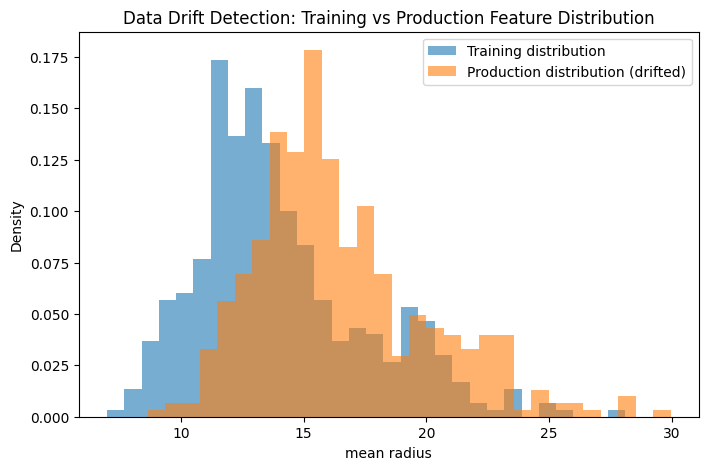

Kolmogorov-Smirnov test: statistic=0.3826, p-value=0.000000
--> p-value < 0.05: statistically significant DRIFT detected. Investigate and consider retraining.


In [11]:
# Simulate and DETECT data drift: compare training feature distribution vs a "shifted" production batch
np.random.seed(12)
training_feature = X_train['mean radius'].values

# Simulate a production batch where sensor/measurement characteristics have subtly shifted
simulated_production_feature = training_feature + np.random.normal(2.5, 0.5, len(training_feature))  # shifted mean

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(training_feature, bins=30, alpha=0.6, label='Training distribution', density=True)
ax.hist(simulated_production_feature, bins=30, alpha=0.6, label='Production distribution (drifted)', density=True)
ax.set_xlabel("mean radius"); ax.set_ylabel("Density")
ax.set_title("Data Drift Detection: Training vs Production Feature Distribution")
ax.legend()
plt.show()

from scipy.stats import ks_2samp
ks_statistic, p_value = ks_2samp(training_feature, simulated_production_feature)
print(f"Kolmogorov-Smirnov test: statistic={ks_statistic:.4f}, p-value={p_value:.6f}")
if p_value < 0.05:
    print("--> p-value < 0.05: statistically significant DRIFT detected. Investigate and consider retraining.")
else:
    print("--> No statistically significant drift detected.")


## 8. Monitoring and Retraining

### What?
**Monitoring**: continuously tracking a deployed model's inputs, outputs, and (when available) ground-truth outcomes to detect problems (drift, degraded accuracy, unusual prediction patterns, latency issues) as early as possible.

**Retraining**: periodically (or trigger-based, upon detecting drift) updating the model with fresh data to keep it aligned with current real-world patterns.

### Why?
No model stays accurate forever in a changing world — monitoring is the "smoke detector," and retraining is the "fix" once smoke is detected. Skipping monitoring means problems are discovered only when they've already caused real business/user harm.

### How? — What to Monitor
- **Input monitoring**: feature distributions (data drift, above), missing value rates, unexpected categories.
- **Output monitoring**: prediction distribution (e.g., is the model suddenly predicting one class far more often?), confidence/calibration (Day 16).
- **Performance monitoring**: accuracy/precision/recall/etc. against ground truth, once available (often delayed — e.g., fraud confirmed weeks later).
- **Retraining triggers**: scheduled (e.g., monthly) vs. **drift-triggered** (retrain as soon as monitoring detects significant drift) vs. **performance-triggered** (retrain once live accuracy drops below a threshold).


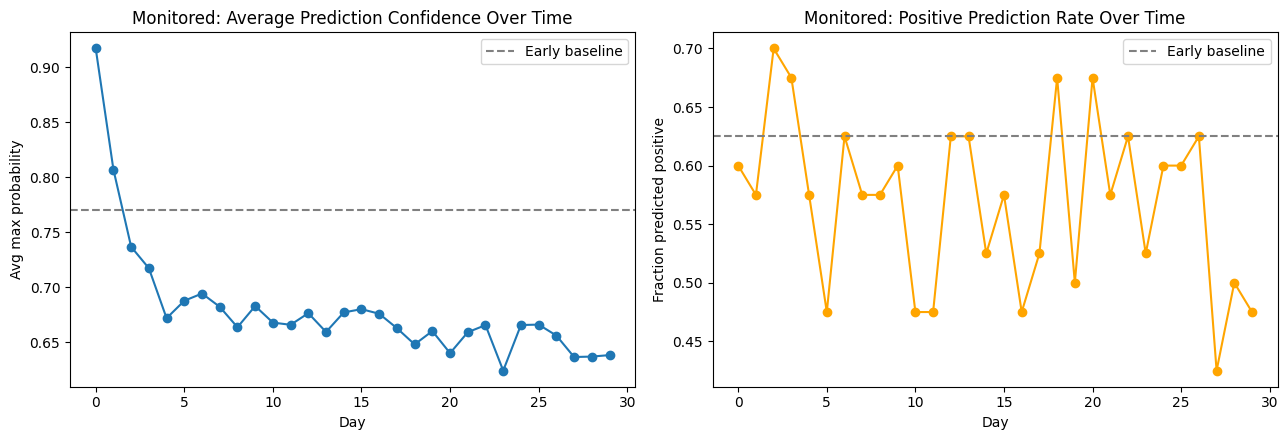

--> A steadily declining confidence trend or a shifting prediction rate, even WITHOUT ground
    truth labels yet available, is an early warning sign worth investigating -- this is exactly
    the kind of dashboard a real monitoring system (e.g., Evidently AI, WhyLabs) would surface.


In [12]:
# Simulate a simple monitoring dashboard: track "live" prediction confidence and class-distribution over time
np.random.seed(13)
n_days = 30
daily_avg_confidence = []
daily_positive_rate = []

for day in range(n_days):
    # Simulate a SLOW drift: confidence gradually decreases, positive-prediction rate gradually shifts
    drift_factor = day / n_days
    simulated_batch = X_test.sample(n=40, random_state=day).copy()
    simulated_batch = simulated_batch + np.random.normal(0, drift_factor * 3, simulated_batch.shape)

    day_probs = model_pipeline.predict_proba(simulated_batch)
    day_preds = model_pipeline.predict(simulated_batch)

    daily_avg_confidence.append(day_probs.max(axis=1).mean())
    daily_positive_rate.append(day_preds.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(daily_avg_confidence, marker='o')
axes[0].axhline(np.mean(daily_avg_confidence[:5]), color='gray', linestyle='--', label='Early baseline')
axes[0].set_title("Monitored: Average Prediction Confidence Over Time")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Avg max probability"); axes[0].legend()

axes[1].plot(daily_positive_rate, marker='o', color='orange')
axes[1].axhline(np.mean(daily_positive_rate[:5]), color='gray', linestyle='--', label='Early baseline')
axes[1].set_title("Monitored: Positive Prediction Rate Over Time")
axes[1].set_xlabel("Day"); axes[1].set_ylabel("Fraction predicted positive"); axes[1].legend()

plt.tight_layout()
plt.show()
print("--> A steadily declining confidence trend or a shifting prediction rate, even WITHOUT ground")
print("    truth labels yet available, is an early warning sign worth investigating -- this is exactly")
print("    the kind of dashboard a real monitoring system (e.g., Evidently AI, WhyLabs) would surface.")


## 9. Deployment Concepts: Data → Preprocessing → Model → API → Docker → Cloud → Monitoring

### What? — The Typical Production ML Pipeline
$$\text{Raw Data} \to \text{Preprocessing (Pipeline)} \to \text{Trained Model} \to \text{Prediction API (e.g., Flask/FastAPI)} \to \text{Docker Container} \to \text{Cloud Deployment (AWS/GCP/Azure)} \to \text{Monitoring}$$

- **API**: wraps the model in an HTTP endpoint (e.g., `POST /predict`) so other applications/services can request predictions without needing Python or the model file directly.
- **Docker**: packages the model, its code, and ALL its dependencies (exact library versions) into a single, portable, reproducible container — solving "works on my machine" for deployment.
- **Cloud deployment**: hosting that container on infrastructure (AWS SageMaker, GCP Vertex AI, Azure ML, or plain Kubernetes) that can scale, handle traffic, and stay available.
- **Monitoring**: the final, ongoing stage (Section 8) — deployment isn't "done" once live; it requires continuous observation.

### Why?
Each stage solves a specific real-world problem: APIs decouple the model from its consumers, Docker solves environment/dependency consistency, cloud infrastructure solves scale/availability, and monitoring solves the "models degrade silently over time" problem (Section 7).

### How?
This pipeline is why **Day 4's `Pipeline` object** and **this day's model serialization** matter so much in practice — the exact same preprocessing + model artifact that worked in your notebook needs to travel, unchanged, through every one of these stages.


## 10. Coding Practice — Save a Model, Expose a Prediction Function, Document a Monitoring Plan


In [13]:
# Save the trained model with versioning metadata (simulating a real model registry entry)
model_metadata = {
    'model_version': 'v1.0.0',
    'model_type': 'RandomForestClassifier (in a Pipeline with StandardScaler)',
    'trained_on': datetime.now().isoformat(),
    'training_data_hash': compute_data_hash(X_train, y_train),
    'hyperparameters': {'n_estimators': 200, 'max_depth': 6},
    'test_accuracy': accuracy_score(y_test, model_pipeline.predict(X_test)),
    'feature_names': X.columns.tolist(),
    'target_names': data.target_names.tolist()
}

with open('/tmp/model_artifacts/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Model metadata saved:")
print(json.dumps(model_metadata, indent=2)[:600] + "...")


Model metadata saved:
{
  "model_version": "v1.0.0",
  "model_type": "RandomForestClassifier (in a Pipeline with StandardScaler)",
  "trained_on": "2026-09-20T09:46:24.150875",
  "training_data_hash": "200570d51b",
  "hyperparameters": {
    "n_estimators": 200,
    "max_depth": 6
  },
  "test_accuracy": 0.958041958041958,
  "feature_names": [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perim...


In [14]:
# Expose a CONCEPTUAL prediction function/API (what a Flask/FastAPI endpoint would wrap)
def predict_endpoint(input_features: dict) -> dict:
    '''
    Simulates a production prediction API endpoint.
    In a real deployment, this function's body would be wrapped by:
        @app.post("/predict")
        def predict(input_features: dict):
            return predict_endpoint(input_features)
    '''
    # Load the model (in production, this would be loaded ONCE at server startup, not per-request)
    with open('/tmp/model_artifacts/breast_cancer_pipeline.pkl', 'rb') as f:
        model = pickle.load(f)

    # Convert the incoming request into the exact feature order the model expects
    input_df = pd.DataFrame([input_features])[data.feature_names]

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]

    return {
        'prediction': data.target_names[prediction],
        'confidence': float(probability.max()),
        'probabilities': dict(zip(data.target_names, probability.round(4).tolist())),
        'model_version': model_metadata['model_version']
    }

# Simulate an incoming API request using one real test sample
example_request = X_test.iloc[0].to_dict()
api_response = predict_endpoint(example_request)

print("Simulated API request/response cycle:\n")
print(f"POST /predict")
print(f"Response: {json.dumps(api_response, indent=2)}")


Simulated API request/response cycle:

POST /predict
Response: {
  "prediction": "benign",
  "confidence": 0.9887915805645788,
  "probabilities": {
    "malignant": 0.0112,
    "benign": 0.9888
  },
  "model_version": "v1.0.0"
}


In [15]:
# Document a concrete monitoring plan (what a real MLOps team would write and operationalize)
monitoring_plan = '''
=== MODEL MONITORING PLAN: Breast Cancer Diagnosis Classifier v1.0.0 ===

1. INPUT MONITORING (Data Drift)
   - Track: mean/std of each of the 30 input features, weekly, vs training-time baseline
   - Method: Kolmogorov-Smirnov test per feature; alert if p < 0.05 for 3+ features simultaneously
   - Also track: missing value rate, out-of-range values (e.g., negative measurements)

2. OUTPUT MONITORING (Prediction Distribution)
   - Track: daily positive-prediction rate and average prediction confidence
   - Alert if: positive rate shifts more than 15% from the 30-day rolling baseline
   - Alert if: average confidence drops more than 10% from baseline (possible sign of drift)

3. PERFORMANCE MONITORING (Ground-Truth Accuracy, once available)
   - Track: accuracy, precision, recall, F1 on newly-confirmed diagnoses, monthly
   - Alert if: recall on malignant cases drops below 95% (clinical safety threshold)

4. RETRAINING TRIGGERS
   - Scheduled: retrain quarterly regardless, to incorporate new confirmed cases
   - Drift-triggered: retrain immediately if data drift alert fires on 3+ features
   - Performance-triggered: retrain immediately if malignant recall drops below 95%

5. VERSIONING & ROLLBACK
   - Every retrained model gets a new version number and is validated against a held-out
     test set before replacing the production model
   - Previous model version is kept available for immediate rollback if the new version
     underperforms on live traffic (canary/shadow deployment recommended)
'''
print(monitoring_plan)

with open('/tmp/model_artifacts/monitoring_plan.txt', 'w') as f:
    f.write(monitoring_plan)



=== MODEL MONITORING PLAN: Breast Cancer Diagnosis Classifier v1.0.0 ===

1. INPUT MONITORING (Data Drift)
   - Track: mean/std of each of the 30 input features, weekly, vs training-time baseline
   - Method: Kolmogorov-Smirnov test per feature; alert if p < 0.05 for 3+ features simultaneously
   - Also track: missing value rate, out-of-range values (e.g., negative measurements)

2. OUTPUT MONITORING (Prediction Distribution)
   - Track: daily positive-prediction rate and average prediction confidence
   - Alert if: positive rate shifts more than 15% from the 30-day rolling baseline
   - Alert if: average confidence drops more than 10% from baseline (possible sign of drift)

3. PERFORMANCE MONITORING (Ground-Truth Accuracy, once available)
   - Track: accuracy, precision, recall, F1 on newly-confirmed diagnoses, monthly
   - Alert if: recall on malignant cases drops below 95% (clinical safety threshold)

4. RETRAINING TRIGGERS
   - Scheduled: retrain quarterly regardless, to incorpora

## 11. One-Page ML Lifecycle Diagram (Daily Output)


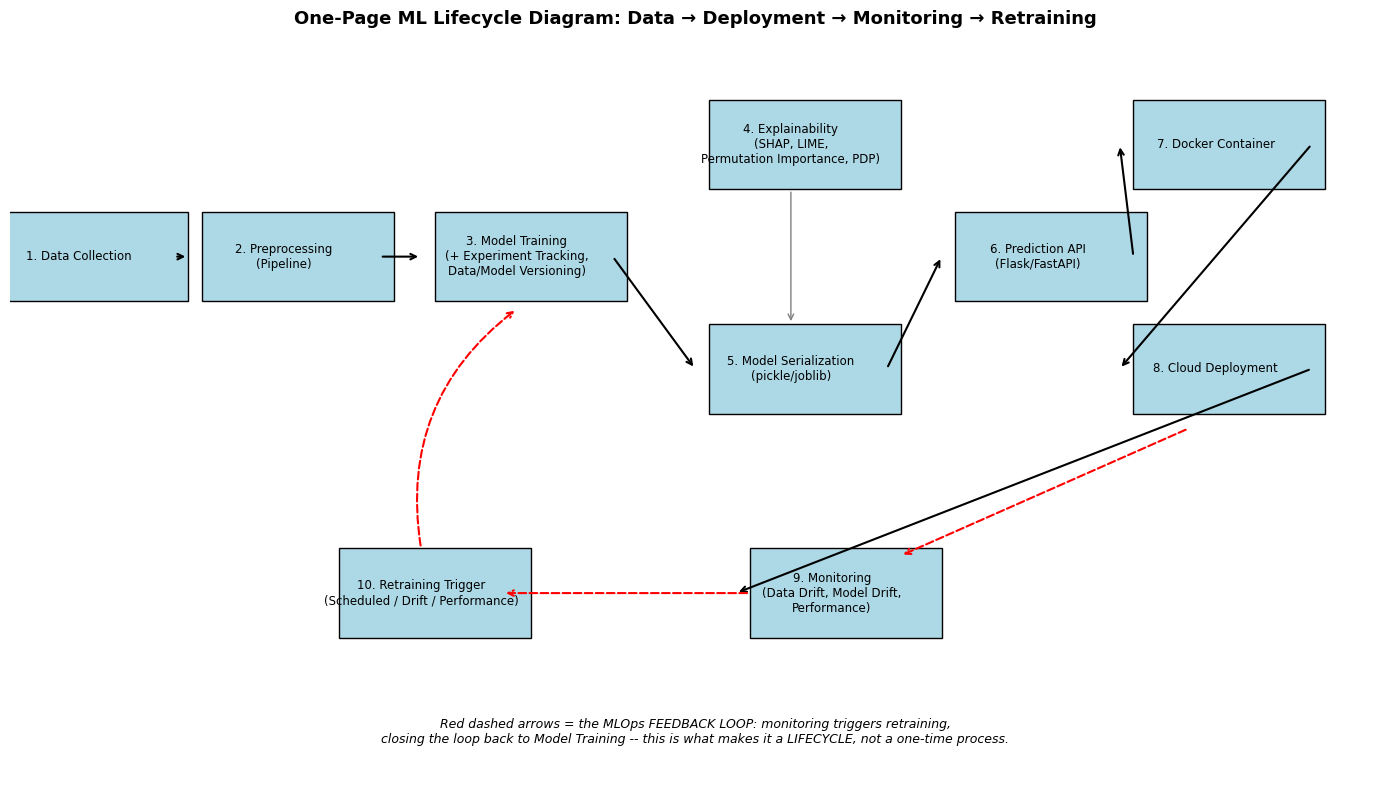

Diagram also saved to /tmp/model_artifacts/ml_lifecycle_diagram.png


In [16]:
# Build a one-page ML lifecycle diagram summarizing the ENTIRE day's content visually
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

stages = [
    ("1. Data Collection", 0.05, 0.7),
    ("2. Preprocessing\n(Pipeline)", 0.20, 0.7),
    ("3. Model Training\n(+ Experiment Tracking,\nData/Model Versioning)", 0.37, 0.7),
    ("4. Explainability\n(SHAP, LIME,\nPermutation Importance, PDP)", 0.57, 0.85),
    ("5. Model Serialization\n(pickle/joblib)", 0.57, 0.55),
    ("6. Prediction API\n(Flask/FastAPI)", 0.75, 0.7),
    ("7. Docker Container", 0.88, 0.85),
    ("8. Cloud Deployment", 0.88, 0.55),
    ("9. Monitoring\n(Data Drift, Model Drift,\nPerformance)", 0.60, 0.25),
    ("10. Retraining Trigger\n(Scheduled / Drift / Performance)", 0.30, 0.25),
]

for label, x, y in stages:
    ax.add_patch(plt.Rectangle((x-0.06, y-0.06), 0.14, 0.12, facecolor='lightblue',
                                 edgecolor='black', zorder=2))
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, zorder=3, wrap=True)

# Main forward flow arrows
flow_pairs = [(0,1), (1,2), (2,4), (4,5), (5,6), (6,7), (7,8)]
for i, j in flow_pairs:
    x1, y1 = stages[i][1], stages[i][2]
    x2, y2 = stages[j][1], stages[j][2]
    ax.annotate('', xy=(x2-0.07, y2), xytext=(x1+0.07, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Explainability branch (parallel to serialization)
ax.annotate('', xy=(0.57, 0.61), xytext=(0.57, 0.79),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Monitoring feedback loop (the critical cyclical part of MLOps)
ax.annotate('', xy=(stages[8][1]+0.05, stages[8][2]+0.05), xytext=(stages[7][1]-0.02, stages[7][2]-0.08),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, linestyle='--'))
ax.annotate('', xy=(stages[9][1]+0.06, stages[9][2]), xytext=(stages[8][1]-0.06, stages[8][2]),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, linestyle='--'))
ax.annotate('', xy=(stages[2][1], stages[2][2]-0.07), xytext=(stages[9][1], stages[9][2]+0.06),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, linestyle='--',
                             connectionstyle="arc3,rad=-0.3"))

ax.text(0.5, 0.05, "Red dashed arrows = the MLOps FEEDBACK LOOP: monitoring triggers retraining,\n"
                    "closing the loop back to Model Training -- this is what makes it a LIFECYCLE, not a one-time process.",
        ha='center', fontsize=9, style='italic')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("One-Page ML Lifecycle Diagram: Data → Deployment → Monitoring → Retraining", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/model_artifacts/ml_lifecycle_diagram.png', dpi=120, bbox_inches='tight')
plt.show()
print("Diagram also saved to /tmp/model_artifacts/ml_lifecycle_diagram.png")


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Permutation Importance | Model-agnostic evaluation, echoing Day 10's held-out evaluation principles |
| SHAP/LIME local explanations | Day 6's log-odds/coefficient interpretation, generalized to any model |
| Pipeline serialization | Day 4/14's Pipeline — now shown to matter for DEPLOYMENT, not just avoiding leakage |
| Data drift detection (KS test) | Day 3's statistical hypothesis testing concepts |
| Retraining triggers | Day 17's chronological data handling — production data keeps arriving over time |


## 12. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Why might permutation importance be preferred over a tree model's built-in feature importance?**
   *Hint: built-in importance can be biased toward high-cardinality/continuous features; permutation importance is model-agnostic and measures actual performance impact on held-out data.*

2. **Explain SHAP values conceptually, and how they differ from LIME.**
   *Hint: SHAP is grounded in Shapley game theory, giving a consistent, theoretically-unique attribution; LIME fits a local linear surrogate model around each prediction, which is faster/simpler but less theoretically grounded and can vary between runs.*

3. **Why should you serialize the entire Pipeline rather than just the raw model?**
   *Hint: guarantees the exact same preprocessing (scaling, encoding) is applied automatically at inference time, preventing train/serve skew bugs.*

4. **What's the difference between data drift and model (concept) drift?**
   *Hint: data drift = input feature distributions change; concept drift = the relationship between features and target itself changes, even if inputs look the same.*

5. **What would you monitor for a deployed ML model, and how would you decide when to retrain?**
   *Hint: input distributions (drift), output/prediction distributions, live performance metrics against ground truth; retrain on a schedule, on drift detection, or on performance degradation below a threshold.*

6. **Why is Docker commonly used when deploying ML models?**
   *Hint: packages code + exact dependency versions into a portable, reproducible container, solving "works on my machine" issues across different deployment environments.*

7. **(Bonus) Why is monitoring described as closing a "feedback loop" in MLOps, rather than being a final, one-time step?**
   *Hint: monitoring's findings (drift, degraded performance) directly trigger retraining, which produces a new model version that gets redeployed and monitored again — an ongoing CYCLE, not a linear one-time pipeline.*


## 13. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain permutation importance and why it's more robust than built-in tree importance.
- [ ] Explain what a Partial Dependence Plot shows.
- [ ] Explain SHAP values conceptually (Shapley game theory, local + global explanations).
- [ ] Explain LIME's local surrogate-model approach and how it differs from SHAP.
- [ ] Explain why the FULL Pipeline (not just the model) should be serialized for deployment.
- [ ] Explain experiment tracking, model versioning, and data versioning, and why each matters.
- [ ] Distinguish data drift from model/concept drift, and describe a detection method for each.
- [ ] Recite the deployment pipeline: Data → Preprocessing → Model → API → Docker → Cloud → Monitoring.
- [ ] Explain the MLOps "feedback loop": monitoring triggers retraining, which redeploys and gets monitored again.

### 📌 Daily Output (per the planner)
A **one-page ML lifecycle diagram** (Section 11) visualizing the complete pipeline from data collection through preprocessing, training (with experiment/data/model versioning), explainability, serialization, API deployment, containerization, cloud hosting, and monitoring — explicitly showing the feedback loop back to retraining that makes this a genuine ongoing *lifecycle* rather than a one-time process. Backed by hands-on code: a saved/reloaded model pipeline, a simulated prediction API, SHAP/LIME/permutation-importance explanations, a data-drift detection experiment, and a written monitoring plan (Section 10).

Close this notebook and redraw the ML lifecycle diagram from memory, including the feedback loop — that's the real test of Day 19 mastery.
